In [1]:
# ── Deep Learning ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# ── Datos y procesamiento ──────────────────────────────
import numpy as np
from PIL import Image
import os
import json
import random
from tqdm import tqdm

# ── Visualización ──────────────────────────────────────
import matplotlib.pyplot as plt

# ── Métricas ───────────────────────────────────────────
from sklearn.metrics import jaccard_score

# ── Verificar GPU disponible ───────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías cargadas")
print(f"🖥️  Dispositivo: {device}")

✅ Librerías cargadas
🖥️  Dispositivo: cpu


In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ── Rutas base ─────────────────────────────────────────
BASE         = '/content/drive/MyDrive/trazos'
DATASET_BASE = os.path.join(BASE, 'dataset', 'fase1_entrenamiento')

PATH_BASICA  = os.path.join(DATASET_BASE, 'geometria_basica')
PATH_RUIDO   = os.path.join(DATASET_BASE, 'ruido')
PATH_MODELOS = os.path.join(BASE, 'modelos', 'fase1')
PATH_LOGS    = os.path.join(BASE, 'logs')

# ── Verificar que existen ──────────────────────────────
rutas = [PATH_BASICA, PATH_RUIDO, PATH_MODELOS, PATH_LOGS]
for r in rutas:
    estado = "✅" if os.path.exists(r) else "❌ NO EXISTE"
    print(f"{estado} — {r}")

Mounted at /content/drive
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/geometria_basica
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/ruido
✅ — /content/drive/MyDrive/trazos/modelos/fase1
✅ — /content/drive/MyDrive/trazos/logs


In [3]:
class TrazosDataset(Dataset):
    """
    Lee pares (input, mask) desde una carpeta con estructura:
        fase/split/inputs/
        fase/split/masks/
    """
    def __init__(self, fase_dir, split, img_size=256):
        self.dir_input = os.path.join(fase_dir, split, 'inputs')
        self.dir_mask  = os.path.join(fase_dir, split, 'masks')
        self.img_size  = img_size
        self.archivos  = sorted(os.listdir(self.dir_input))

        self.transform_img = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),                        # [0,255] → [0,1]
            transforms.Normalize([0.5,0.5,0.5],          # normalizar RGB
                                 [0.5,0.5,0.5])
        ])
        self.transform_mask = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()                         # mask → [0,1]
        ])

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        nombre = self.archivos[idx]
        img  = Image.open(os.path.join(self.dir_input, nombre)).convert('RGB')
        mask = Image.open(os.path.join(self.dir_mask,  nombre)).convert('L')
        return self.transform_img(img), self.transform_mask(mask)


# ── Cargar los dos datasets de Fase 1 ─────────────────
# Combinamos geometría básica + ruido en train y val
from torch.utils.data import ConcatDataset

train_basica = TrazosDataset(PATH_BASICA, 'train')
train_ruido  = TrazosDataset(PATH_RUIDO,  'train')
train_dataset = ConcatDataset([train_basica, train_ruido])

val_basica   = TrazosDataset(PATH_BASICA, 'val')
val_ruido    = TrazosDataset(PATH_RUIDO,  'val')
val_dataset  = ConcatDataset([val_basica, val_ruido])

test_basica  = TrazosDataset(PATH_BASICA, 'test')
test_ruido   = TrazosDataset(PATH_RUIDO,  'test')
test_dataset = ConcatDataset([test_basica, test_ruido])

print(f"✅ Dataset cargado")
print(f"   Train : {len(train_dataset):>5} imágenes")
print(f"   Val   : {len(val_dataset):>5} imágenes")
print(f"   Test  : {len(test_dataset):>5} imágenes")
print(f"   Total : {len(train_dataset)+len(val_dataset)+len(test_dataset):>5} imágenes")

✅ Dataset cargado
   Train :  2000 imágenes
   Val   :   400 imágenes
   Test  :   400 imágenes
   Total :  2800 imágenes


In [5]:
def revisar_calidad(dataset_path, split, n_muestras=50):
    dir_input = os.path.join(dataset_path, split, 'inputs')
    dir_mask  = os.path.join(dataset_path, split, 'masks')
    archivos  = sorted(os.listdir(dir_input))[:n_muestras]

    masks_vacias    = 0
    inputs_corruptos = 0
    errores          = []

    for nombre in archivos:
        try:
            img  = Image.open(os.path.join(dir_input, nombre))
            mask = Image.open(os.path.join(dir_mask,  nombre))
            arr_mask = np.array(mask)
            if arr_mask.max() == 0:
                masks_vacias += 1
                errores.append(nombre)
        except Exception as e:
            inputs_corruptos += 1
            errores.append(f"{nombre} — ERROR: {e}")

    print(f"📊 Revisión: {dataset_path.split('/')[-1]} / {split}")
    print(f"   Muestras revisadas : {n_muestras}")
    print(f"   Masks vacías       : {masks_vacias}")
    print(f"   Inputs corruptos   : {inputs_corruptos}")
    if errores:
        print(f"   ⚠️  Archivos con problema:")
        for e in errores[:5]:
            print(f"      {e}")
    else:
        print(f"   ✅ Sin problemas detectados")
    print()

revisar_calidad(PATH_BASICA, 'train')
revisar_calidad(PATH_RUIDO,  'train')
revisar_calidad(PATH_BASICA, 'val')
revisar_calidad(PATH_RUIDO,  'val')

📊 Revisión: geometria_basica / train
   Muestras revisadas : 50
   Masks vacías       : 0
   Inputs corruptos   : 0
   ✅ Sin problemas detectados

📊 Revisión: ruido / train
   Muestras revisadas : 50
   Masks vacías       : 0
   Inputs corruptos   : 0
   ✅ Sin problemas detectados

📊 Revisión: geometria_basica / val
   Muestras revisadas : 50
   Masks vacías       : 0
   Inputs corruptos   : 0
   ✅ Sin problemas detectados

📊 Revisión: ruido / val
   Muestras revisadas : 50
   Masks vacías       : 0
   Inputs corruptos   : 0
   ✅ Sin problemas detectados



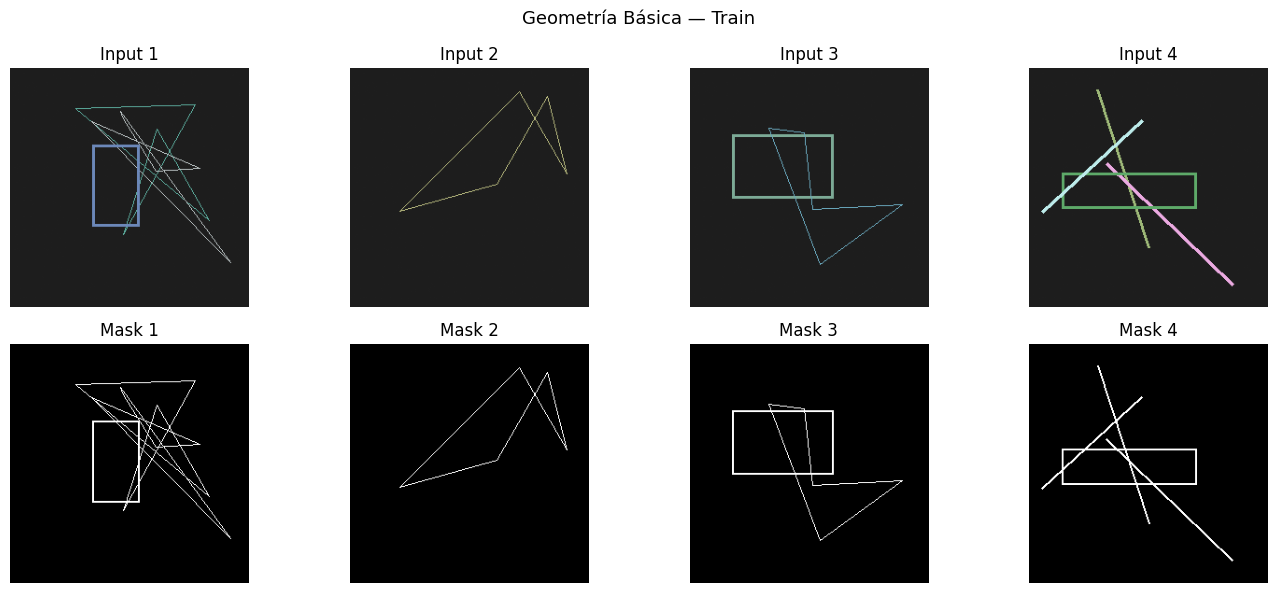

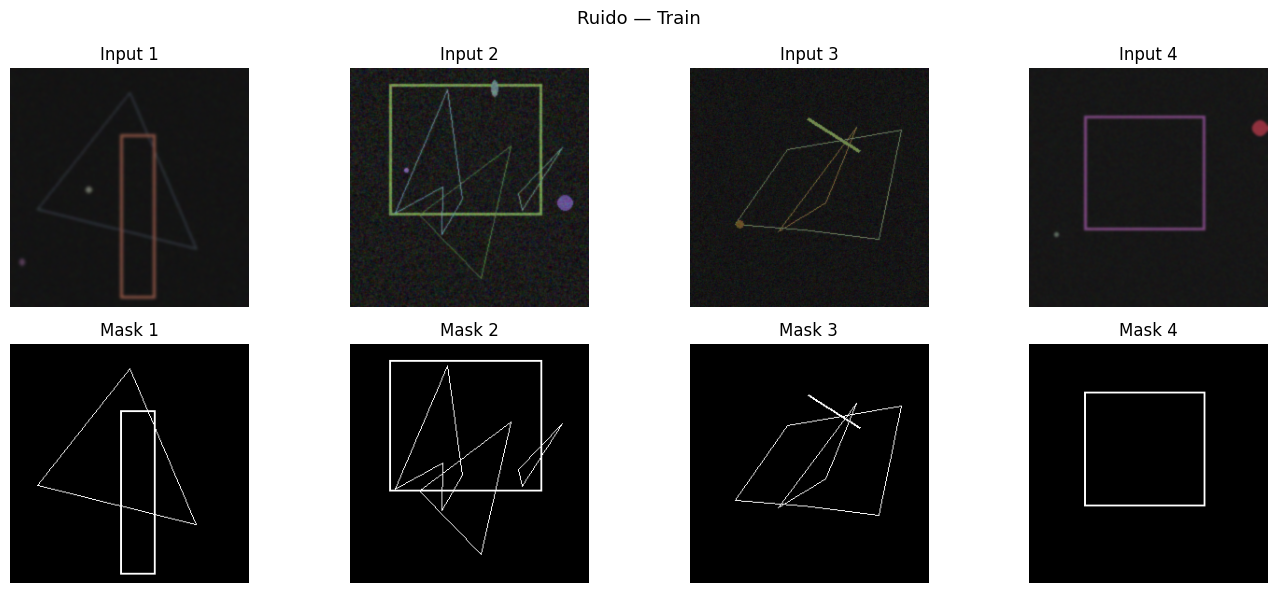

In [6]:
def visualizar_pares(dataset, titulo, n=4):
    fig, axes = plt.subplots(2, n, figsize=(14, 6))
    fig.suptitle(titulo, fontsize=13)

    indices = random.sample(range(len(dataset)), n)

    for col, idx in enumerate(indices):
        img_tensor, mask_tensor = dataset[idx]

        # Desnormalizar imagen para visualizar
        img_np  = img_tensor.permute(1,2,0).numpy()
        img_np  = (img_np * 0.5 + 0.5).clip(0,1)
        mask_np = mask_tensor.squeeze().numpy()

        axes[0][col].imshow(img_np)
        axes[0][col].set_title(f'Input {col+1}')
        axes[0][col].axis('off')

        axes[1][col].imshow(mask_np, cmap='gray')
        axes[1][col].set_title(f'Mask {col+1}')
        axes[1][col].axis('off')

    plt.tight_layout()
    plt.show()

visualizar_pares(train_basica, 'Geometría Básica — Train')
visualizar_pares(train_ruido,  'Ruido — Train')

In [7]:
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f"✅ DataLoaders listos")
print(f"   Batches train : {len(train_loader)}")
print(f"   Batches val   : {len(val_loader)}")
print(f"   Batches test  : {len(test_loader)}")

✅ DataLoaders listos
   Batches train : 125
   Batches val   : 25
   Batches test  : 25


In [8]:
import cv2

def evaluar_canny(dataset_path, split, n_muestras=100):
    dir_input = os.path.join(dataset_path, split, 'inputs')
    dir_mask  = os.path.join(dataset_path, split, 'masks')
    archivos  = sorted(os.listdir(dir_input))[:n_muestras]

    ious = []

    for nombre in archivos:
        img  = cv2.imread(os.path.join(dir_input, nombre))
        mask = np.array(Image.open(os.path.join(dir_mask, nombre)))

        gris  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        canny = cv2.Canny(gris, 50, 150)

        # Binarizar ambos
        pred = (canny > 0).astype(np.uint8).flatten()
        gt   = (mask  > 127).astype(np.uint8).flatten()

        iou = jaccard_score(gt, pred, zero_division=0)
        ious.append(iou)

    media_iou = np.mean(ious)
    print(f"📊 Baseline Canny — {dataset_path.split('/')[-1]} / {split}")
    print(f"   IoU promedio: {media_iou:.4f}")
    return media_iou

iou_canny_basica = evaluar_canny(PATH_BASICA, 'val')
iou_canny_ruido  = evaluar_canny(PATH_RUIDO,  'val')

BASELINE_IOU = (iou_canny_basica + iou_canny_ruido) / 2
print(f"\n🎯 Baseline IoU combinado: {BASELINE_IOU:.4f}")
print(f"   → Nuestra IA debe superar este valor para ser útil")

📊 Baseline Canny — geometria_basica / val
   IoU promedio: 0.0765
📊 Baseline Canny — ruido / val
   IoU promedio: 0.0344

🎯 Baseline IoU combinado: 0.0555
   → Nuestra IA debe superar este valor para ser útil


In [9]:
class CNNBaseline(nn.Module):
    """
    CNN simple de encoder-decoder.
    Input:  [B, 3, 256, 256] — imagen RGB normalizada
    Output: [B, 1, 256, 256] — mask de probabilidades
    """
    def __init__(self):
        super().__init__()

        # Encoder — extrae características
        self.encoder = nn.Sequential(
            nn.Conv2d(3,  16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        # Decoder — reconstruye la mask
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 2, stride=2), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, 2, stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


modelo = CNNBaseline().to(device)

# Contar parámetros
total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"✅ CNN Baseline creada")
print(f"   Parámetros entrenables: {total_params:,}")

✅ CNN Baseline creada
   Parámetros entrenables: 33,937


In [12]:
# ── Loss ───────────────────────────────────────────────
# BCELoss: Binary Cross Entropy — ideal para segmentación binaria
criterion = nn.BCELoss()

# ── Optimizer ──────────────────────────────────────────
optimizer = optim.Adam(modelo.parameters(), lr=1e-3)

# ── Scheduler — reduce LR si val_loss no mejora ────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Configuración general ──────────────────────────────
CONFIG = {
    'version'    : 'v1_cnn_baseline',
    'epochs'     : 50,
    'batch_size' : BATCH_SIZE,
    'lr'         : 1e-3,
    'img_size'   : 256,
    'optimizer'  : 'Adam',
    'loss'       : 'BCELoss',
    'patience'   : 10,        # EarlyStopping
}

print("✅ Configuración lista")
for k, v in CONFIG.items():
    print(f"   {k:15}: {v}")

✅ Configuración lista
   version        : v1_cnn_baseline
   epochs         : 50
   batch_size     : 16
   lr             : 0.001
   img_size       : 256
   optimizer      : Adam
   loss           : BCELoss
   patience       : 10


In [13]:
def calcular_iou(pred, target, threshold=0.5):
    """
    Intersection over Union — qué tan bien se superpone
    la predicción con la mask real.
    Valor 0 = sin overlap | 1 = perfecto
    """
    pred   = (pred > threshold).float()
    inter  = (pred * target).sum()
    union  = (pred + target).clamp(0,1).sum()
    return (inter / (union + 1e-8)).item()

def calcular_dice(pred, target, threshold=0.5):
    """
    Dice Score — similar a IoU pero penaliza menos
    los fallos en áreas pequeñas.
    Valor 0 = sin overlap | 1 = perfecto
    """
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    return (2 * inter / (pred.sum() + target.sum() + 1e-8)).item()

print("✅ Métricas definidas: IoU, Dice Score")

✅ Métricas definidas: IoU, Dice Score


In [14]:
def entrenar(modelo, train_loader, val_loader, config, path_modelo, path_log):

    mejor_val_loss = float('inf')
    epochs_sin_mejora = 0
    historial = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}

    for epoch in range(config['epochs']):

        # ── TRAIN ──────────────────────────────────────
        modelo.train()
        train_loss_total = 0

        for imgs, masks in train_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            preds = modelo(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()

        train_loss = train_loss_total / len(train_loader)

        # ── VALIDACIÓN ─────────────────────────────────
        modelo.eval()
        val_loss_total = 0
        iou_total      = 0
        dice_total     = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device)
                preds = modelo(imgs)

                val_loss_total += criterion(preds, masks).item()
                iou_total      += calcular_iou(preds, masks)
                dice_total     += calcular_dice(preds, masks)

        val_loss  = val_loss_total / len(val_loader)
        val_iou   = iou_total      / len(val_loader)
        val_dice  = dice_total     / len(val_loader)

        # ── Scheduler ──────────────────────────────────
        scheduler.step(val_loss)

        # ── Guardar historial ──────────────────────────
        historial['train_loss'].append(train_loss)
        historial['val_loss']  .append(val_loss)
        historial['val_iou']   .append(val_iou)
        historial['val_dice']  .append(val_dice)

        # ── Log por época ──────────────────────────────
        print(f"Época {epoch+1:03d}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"IoU: {val_iou:.4f} | "
              f"Dice: {val_dice:.4f}")

        # ── Guardar mejor modelo ───────────────────────
        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            epochs_sin_mejora = 0
            torch.save(modelo.state_dict(), os.path.join(path_modelo, 'best_model.pth'))
            print(f"           💾 Mejor modelo guardado (val_loss: {mejor_val_loss:.4f})")
        else:
            epochs_sin_mejora += 1

        # ── EarlyStopping ──────────────────────────────
        if epochs_sin_mejora >= config['patience']:
            print(f"\n⛔ EarlyStopping en época {epoch+1}")
            break

    # ── Guardar log completo ───────────────────────────
    log = {'config': config, 'historial': historial, 'mejor_val_loss': mejor_val_loss}
    with open(os.path.join(path_log, f"{config['version']}.json"), 'w') as f:
        json.dump(log, f, indent=4)

    print(f"\n✅ Entrenamiento finalizado")
    print(f"   Mejor Val Loss : {mejor_val_loss:.4f}")
    print(f"   Log guardado   : {config['version']}.json")

    return historial


# ── Ejecutar entrenamiento ─────────────────────────────
historial = entrenar(modelo, train_loader, val_loader, CONFIG, PATH_MODELOS, PATH_LOGS)

Época 001/50 | Train Loss: 0.1867 | Val Loss: 0.0906 | IoU: 0.0000 | Dice: 0.0000
           💾 Mejor modelo guardado (val_loss: 0.0906)
Época 002/50 | Train Loss: 0.0718 | Val Loss: 0.0522 | IoU: 0.0383 | Dice: 0.0732
           💾 Mejor modelo guardado (val_loss: 0.0522)
Época 003/50 | Train Loss: 0.0467 | Val Loss: 0.0432 | IoU: 0.1844 | Dice: 0.3098
           💾 Mejor modelo guardado (val_loss: 0.0432)
Época 004/50 | Train Loss: 0.0410 | Val Loss: 0.0389 | IoU: 0.3003 | Dice: 0.4594
           💾 Mejor modelo guardado (val_loss: 0.0389)
Época 005/50 | Train Loss: 0.0371 | Val Loss: 0.0355 | IoU: 0.3806 | Dice: 0.5492
           💾 Mejor modelo guardado (val_loss: 0.0355)
Época 006/50 | Train Loss: 0.0343 | Val Loss: 0.0332 | IoU: 0.3958 | Dice: 0.5653
           💾 Mejor modelo guardado (val_loss: 0.0332)
Época 007/50 | Train Loss: 0.0323 | Val Loss: 0.0317 | IoU: 0.4043 | Dice: 0.5742
           💾 Mejor modelo guardado (val_loss: 0.0317)
Época 008/50 | Train Loss: 0.0308 | Val Loss: 0.

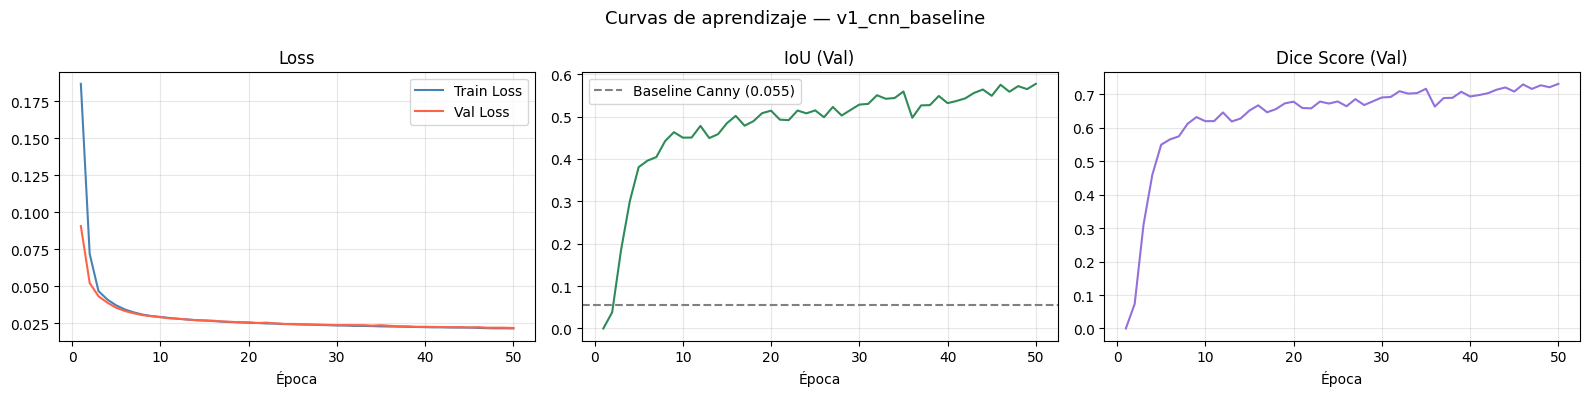

💾 Curvas guardadas en logs/


In [15]:
def graficar_curvas(historial, version):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Curvas de aprendizaje — {version}', fontsize=13)
    epochs = range(1, len(historial['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs, historial['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, historial['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # IoU
    axes[1].plot(epochs, historial['val_iou'], color='seagreen')
    axes[1].axhline(y=BASELINE_IOU, color='gray', linestyle='--', label=f'Baseline Canny ({BASELINE_IOU:.3f})')
    axes[1].set_title('IoU (Val)')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Dice
    axes[2].plot(epochs, historial['val_dice'], color='mediumpurple')
    axes[2].set_title('Dice Score (Val)')
    axes[2].set_xlabel('Época')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH_LOGS, f"{CONFIG['version']}_curvas.png"), dpi=100)
    plt.show()
    print(f"💾 Curvas guardadas en logs/")

graficar_curvas(historial, CONFIG['version'])

In [16]:
# Cargar mejor modelo
modelo.load_state_dict(torch.load(os.path.join(PATH_MODELOS, 'best_model.pth')))
modelo.eval()

test_loss_total = 0
iou_total       = 0
dice_total      = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        preds = modelo(imgs)

        test_loss_total += criterion(preds, masks).item()
        iou_total       += calcular_iou(preds, masks)
        dice_total      += calcular_dice(preds, masks)

test_loss = test_loss_total / len(test_loader)
test_iou  = iou_total       / len(test_loader)
test_dice = dice_total      / len(test_loader)

print("=" * 50)
print("📊 EVALUACIÓN FINAL EN TEST")
print("=" * 50)
print(f"   Test Loss  : {test_loss:.4f}")
print(f"   Test IoU   : {test_iou:.4f}  (Baseline Canny: {BASELINE_IOU:.4f})")
print(f"   Test Dice  : {test_dice:.4f}")
print()
if test_iou > BASELINE_IOU:
    print(f"   ✅ La IA supera al baseline Canny")
else:
    print(f"   ⚠️  La IA NO supera al baseline — revisar arquitectura")
print("=" * 50)

📊 EVALUACIÓN FINAL EN TEST
   Test Loss  : 0.0215
   Test IoU   : 0.5833  (Baseline Canny: 0.0555)
   Test Dice  : 0.7363

   ✅ La IA supera al baseline Canny


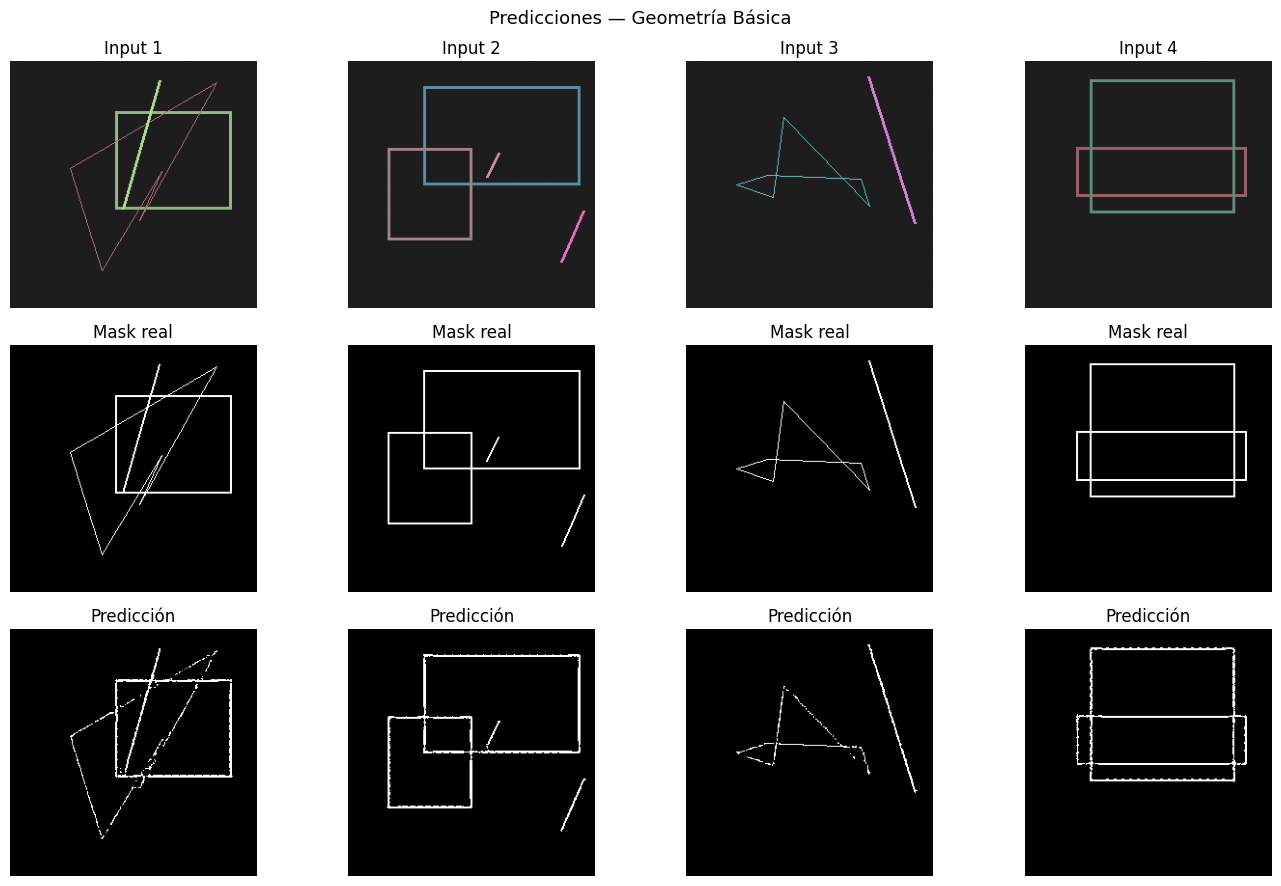

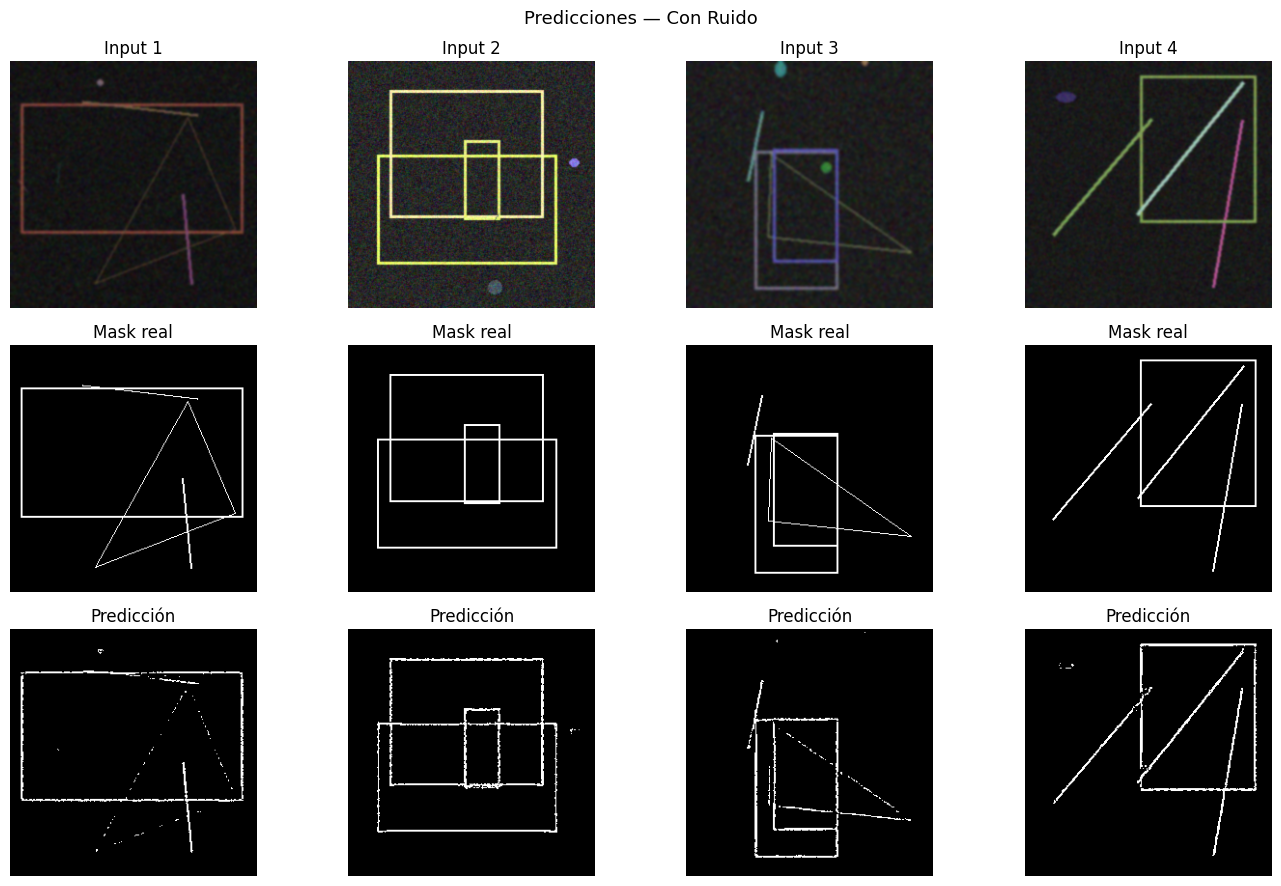

In [17]:
def visualizar_predicciones(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(titulo, fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred = modelo(img_tensor.unsqueeze(0).to(device))
            pred = pred.squeeze().cpu().numpy()

            # Desnormalizar imagen
            img_np  = img_tensor.permute(1,2,0).numpy()
            img_np  = (img_np * 0.5 + 0.5).clip(0,1)
            mask_np = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)

            axes[0][col].imshow(img_np)
            axes[0][col].set_title(f'Input {col+1}')
            axes[0][col].axis('off')

            axes[1][col].imshow(mask_np, cmap='gray')
            axes[1][col].set_title('Mask real')
            axes[1][col].axis('off')

            axes[2][col].imshow(pred_bin, cmap='gray')
            axes[2][col].set_title(f'Predicción')
            axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

visualizar_predicciones(modelo, test_basica, 'Predicciones — Geometría Básica')
visualizar_predicciones(modelo, test_ruido,  'Predicciones — Con Ruido')

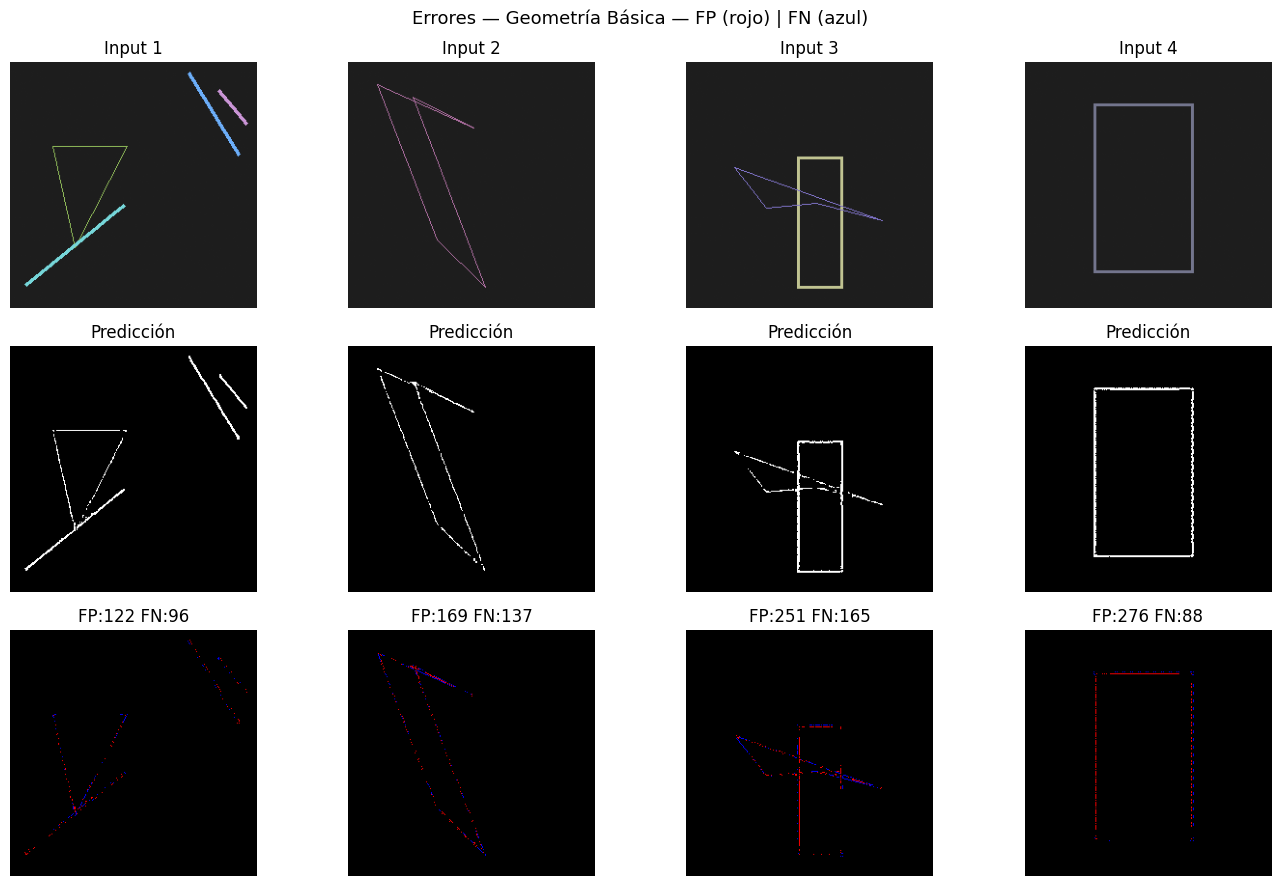

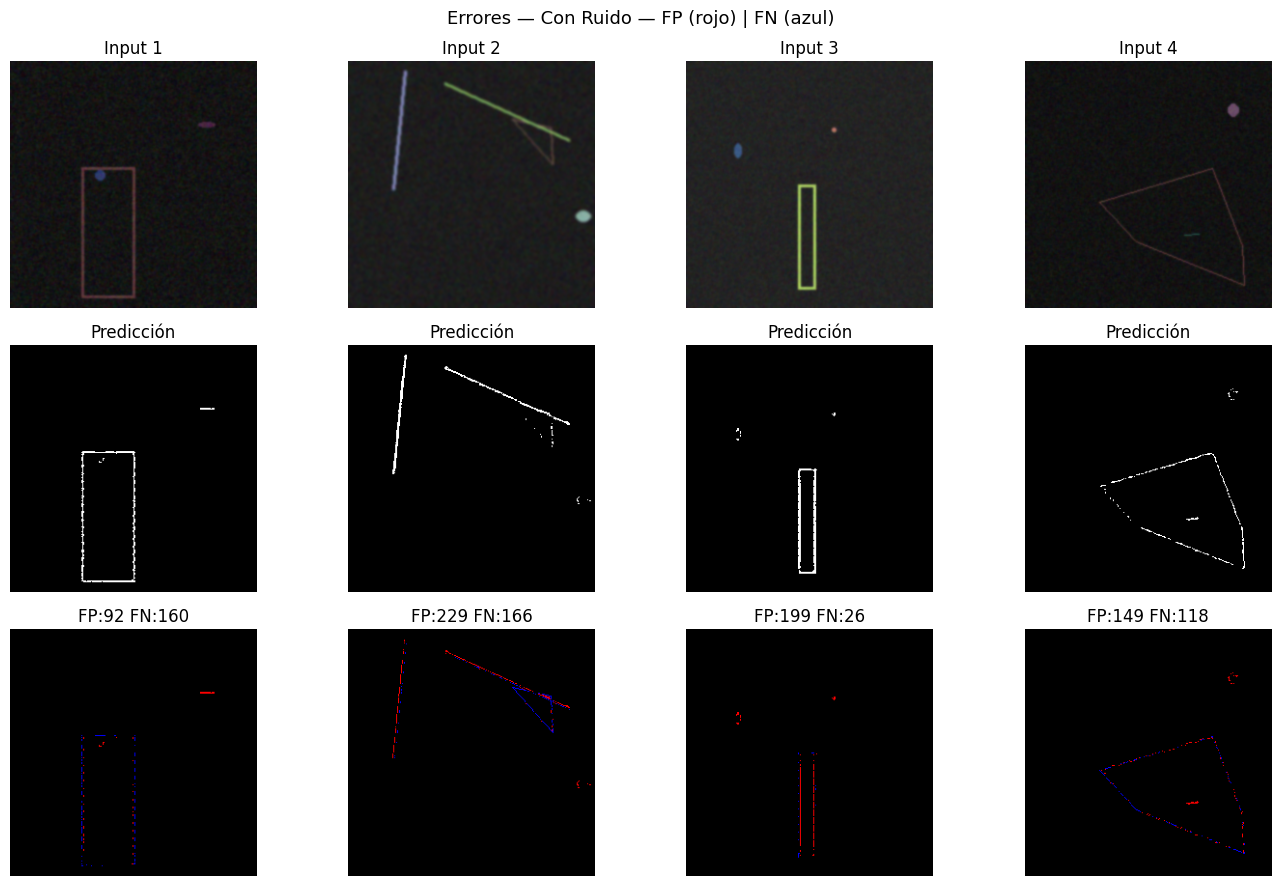

In [18]:
def analizar_errores(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(f'{titulo} — FP (rojo) | FN (azul)', fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred = modelo(img_tensor.unsqueeze(0).to(device))
            pred = pred.squeeze().cpu().numpy()

            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)
            gt_bin   = (mask_np > 0.5).astype(np.float32)

            # FP: predice 1 pero era 0
            fp = ((pred_bin == 1) & (gt_bin == 0)).astype(np.float32)
            # FN: predice 0 pero era 1
            fn = ((pred_bin == 0) & (gt_bin == 1)).astype(np.float32)

            # Imagen de error: FP=rojo, FN=azul
            error_img = np.zeros((*gt_bin.shape, 3))
            error_img[:,:,0] = fp   # rojo = FP
            error_img[:,:,2] = fn   # azul = FN

            img_np = img_tensor.permute(1,2,0).numpy()
            img_np = (img_np * 0.5 + 0.5).clip(0,1)

            axes[0][col].imshow(img_np)
            axes[0][col].set_title(f'Input {col+1}')
            axes[0][col].axis('off')

            axes[1][col].imshow(pred_bin, cmap='gray')
            axes[1][col].set_title('Predicción')
            axes[1][col].axis('off')

            axes[2][col].imshow(error_img)
            fp_count = int(fp.sum())
            fn_count = int(fn.sum())
            axes[2][col].set_title(f'FP:{fp_count} FN:{fn_count}')
            axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

analizar_errores(modelo, test_basica, 'Errores — Geometría Básica')
analizar_errores(modelo, test_ruido,  'Errores — Con Ruido')

In [19]:
resultados = {
    'Versión'         : CONFIG['version'],
    'Arquitectura'    : 'CNN Baseline',
    'Baseline Canny'  : f"{BASELINE_IOU:.4f}",
    'Test IoU'        : f"{test_iou:.4f}",
    'Test Dice'       : f"{test_dice:.4f}",
    'Test Loss'       : f"{test_loss:.4f}",
    'Supera Baseline' : "✅ Sí" if test_iou > BASELINE_IOU else "❌ No",
}

print("=" * 50)
print("📋 RESUMEN VERSIÓN ACTUAL")
print("=" * 50)
for k, v in resultados.items():
    print(f"   {k:20}: {v}")
print("=" * 50)

# Guardar resumen en log
resumen_path = os.path.join(PATH_LOGS, f"{CONFIG['version']}_resumen.json")
with open(resumen_path, 'w') as f:
    json.dump(resultados, f, indent=4, ensure_ascii=False)

print(f"\n💾 Resumen guardado en logs/")

📋 RESUMEN VERSIÓN ACTUAL
   Versión             : v1_cnn_baseline
   Arquitectura        : CNN Baseline
   Baseline Canny      : 0.0555
   Test IoU            : 0.5833
   Test Dice           : 0.7363
   Test Loss           : 0.0215
   Supera Baseline     : ✅ Sí

💾 Resumen guardado en logs/


In [20]:
def inferencia(ruta_imagen, modelo, threshold=0.5, img_size=256):
    """
    Recibe la ruta de cualquier imagen y devuelve
    la imagen original con el overlay estructural superpuesto.
    """
    modelo.eval()

    # Cargar y preprocesar
    img = Image.open(ruta_imagen).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predicción
    with torch.no_grad():
        pred = modelo(img_tensor).squeeze().cpu().numpy()

    pred_bin = (pred > threshold).astype(np.float32)

    # Visualizar
    img_np = np.array(img.resize((img_size, img_size))) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('Inferencia as_built', fontsize=13)

    axes[0].imshow(img_np)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')

    axes[1].imshow(pred_bin, cmap='gray')
    axes[1].set_title('Overlay predicho')
    axes[1].axis('off')

    # Overlay sobre imagen original
    overlay = img_np.copy()
    overlay[pred_bin == 1] = [0, 1, 0]  # verde = estructura detectada
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay superpuesto')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_bin

# ── Ejemplo de uso ─────────────────────────────────────
# resultado = inferencia('/ruta/a/tu/imagen.png', modelo)
print("✅ Función de inferencia lista")
print("   Uso: inferencia('/imagenes_de_ejemplo/Estanteria.png', modelo)")

✅ Función de inferencia lista
   Uso: inferencia('/imagenes_de_ejemplo/Estanteria.png', modelo)


In [21]:
resumen_version = """
=======================================================
RESUMEN — as_built | {version}
=======================================================

QUÉ SE HIZO:
- Dataset Fase 1: geometría básica (1400 imgs) + ruido (1400 imgs)
- Arquitectura CNN simple encoder-decoder
- Entrenamiento con BCELoss + Adam + EarlyStopping
- Evaluación con IoU, Dice Score y comparación vs Canny baseline

RESULTADOS:
- Baseline Canny IoU : {baseline}
- Test IoU           : {test_iou}
- Test Dice          : {test_dice}
- ¿Supera baseline?  : {supera}

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

PRÓXIMA VERSIÓN:
- Migrar a U-Net para mejor precisión estructural
- Evaluar si se necesita más variedad en el dataset
=======================================================
""".format(
    version  = CONFIG['version'],
    baseline = f"{BASELINE_IOU:.4f}",
    test_iou = f"{test_iou:.4f}",
    test_dice= f"{test_dice:.4f}",
    supera   = "Sí" if test_iou > BASELINE_IOU else "No"
)

print(resumen_version)

# Guardar resumen textual
with open(os.path.join(PATH_LOGS, f"{CONFIG['version']}_notas.txt"), 'w') as f:
    f.write(resumen_version)

print("💾 Notas guardadas en logs/")


RESUMEN — as_built | v1_cnn_baseline

QUÉ SE HIZO:
- Dataset Fase 1: geometría básica (1400 imgs) + ruido (1400 imgs)
- Arquitectura CNN simple encoder-decoder
- Entrenamiento con BCELoss + Adam + EarlyStopping
- Evaluación con IoU, Dice Score y comparación vs Canny baseline

RESULTADOS:
- Baseline Canny IoU : 0.0555
- Test IoU           : 0.5833
- Test Dice          : 0.7363
- ¿Supera baseline?  : Sí

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

PRÓXIMA VERSIÓN:
- Migrar a U-Net para mejor precisión estructural
- Evaluar si se necesita más variedad en el dataset

💾 Notas guardadas en logs/
